In [1]:
from copy import deepcopy as cp
from tqdm import tqdm
import numpy as np
import pandas as pd
import codecs
import re

In [2]:
from sklearn.metrics import ConfusionMatrixDisplay
from experimental.display import create_tsne_for_plot
from experimental.metrics import bcb_clust

## Загрузка датасета

In [3]:
df = pd.read_pickle("statistics_and_text.pkl")
tlen = [len(elm) for elm in df["textInFile"]]
df["tlen"] = tlen
df = df[df["tlen"] > 100]

df = df[df['textInFile'].str.contains('УДК')]
n_pos_s = list(df['textInFile'].str.find('УДК'))

udk = []
udk2 = []
udk3 = []
udk31 = []
i = 0
for tx in tqdm(df['textInFile']):
    
    end = tx.find("\n", n_pos_s[i]+4)
    # print(tx[n_pos_s[i]+4:end])
    tx2 = tx[n_pos_s[i]+4:end].strip().replace("�", "-").replace("\t", ";").replace(" ", ";").replace(",", ";").replace("+", ";").replace(":", ";").replace("00", "0").replace(".", "")
    tx2 = re.sub("\([\w;.]+\)", "",tx2)
    tx2 = re.sub("[ ]+", " ",tx2)
    tx2 = tx2.replace(" - ", "-").split(";")
    tx2 = [tx_ for tx_ in tx2 if tx_ != "" and any(c.isalpha() for c in tx_) is False and len(tx_) < 25 and "�" not in tx_ and "?" not in tx_]
    #print(tx2)
    udk2_ = []
    udk2_2 = []
    
    for t in tx2:
        try:
            if t[:2] in ['01', '02', '04', '05', '06', '07', '30', '31', '32', '33', '34',
        '35', '36', '37', '50', '51', '52', '53', '54', '55', '57', '61',
        '62', '63', '65', '66', '68']:
                udk2_.append(t[:2])
                udk2_2.append(t[0])
        except:
            continue
    udk.append(np.unique(udk2_).tolist())
    udk3.append("".join(np.unique(udk2_).tolist()))
    udk31.append("".join(np.unique(udk2_2).tolist()))
    # print(udk[-1])
    udk2.append(len(udk[-1]))
    i += 1

df["УДК"] = udk
df["УДК-sp1"] = udk3
df["УДК-sp2"] = udk31
df["УДК-ln"] = udk2
print(len(df["textInFile"]))
df = df[df["УДК-ln"] != 0]
print(len(df["textInFile"]))
good_texts = []

<>:19: SyntaxWarning: invalid escape sequence '\('
<>:19: SyntaxWarning: invalid escape sequence '\('
C:\Users\User\AppData\Local\Temp\ipykernel_12004\3571163597.py:19: SyntaxWarning: invalid escape sequence '\('
  tx2 = re.sub("\([\w;.]+\)", "",tx2)
100%|██████████| 4350/4350 [00:00<00:00, 11982.32it/s]

4350
4246


## Предобработка

1. Добавить проверку на то, что перед нами слова русского языка (а не рандомные наборы букв, такое бывает)

In [4]:
all_texts = list(df["textInFile"])
all_udcc = [int(elm[0]) for elm in list(df["УДК-sp2"])]

In [5]:
np.random.seed(0)
selection_ids = np.random.choice(len(all_texts), 500, replace=False, )
all_texts = [all_texts[i] for i in selection_ids]
all_udcc = [all_udcc[i] for i in selection_ids]

In [6]:
## удаление лишних символов, удаление необрабатываемых символов, удаление слишком коротких текстов.

red_texts = []
red_udcc = []
for i in tqdm(range(len(all_texts))):
    rt = all_texts[i].replace('-\n', '')
    rt = rt.replace('\n', ' ')
    rt = re.sub(r'[^а-яё.,:()\[\]0-9А-Я]', ' ', rt)
    # rt = re.sub(r'\s[а-яё.,:()0-9А-Я]\s', ' ', rt)
    rt = rt.replace(' . ', ' ')
    rt = re.sub('\s+', ' ', rt)
    rt = rt.split('.')
    rt = '. '.join([elm.strip() for elm in rt if elm.strip() !=''])
    if(len(rt) > 300):
        if red_texts != [] and red_texts[-1] == rt:
            continue
        red_texts.append(rt)
        red_udcc.append(all_udcc[i])

<>:11: SyntaxWarning: invalid escape sequence '\s'
<>:11: SyntaxWarning: invalid escape sequence '\s'
C:\Users\User\AppData\Local\Temp\ipykernel_12004\3135022001.py:11: SyntaxWarning: invalid escape sequence '\s'
  rt = re.sub('\s+', ' ', rt)
100%|██████████| 500/500 [00:06<00:00, 81.10it/s] 


In [7]:
r = re.search(' [а-яё]', 'а Также ключевыве слова')
print(r)

<re.Match object; span=(7, 9), match=' к'>


In [8]:
r = re.findall('[А-ЯЁ]', 'а Также ключевыве слова')
print(r)

['Т']


In [9]:
## Разделение текстов на фрагменты (предложения). Удаление слишком длинных предложений
split_texts = []
for cur_text in tqdm(red_texts):
    split_text = []
    join_next = False
    keywords_rem = False
    cnt = -1
    ps = None
    
    for sent in re.split(r'([а-яё]\. )', cur_text):
        cnt += 1
        if cnt % 2 != 0:
            sent = ps + sent[:-2]
        else:
            ps = cp(sent)
            continue


        # останавливаемся, если дошли до списка литературы
        if re.search('список литературы', sent.lower()) is not None: 
            break
        
        if len(sent) > 1000:
            continue
        if len(sent) < 30:
            continue
        
        # убираем предложения, где слишком много больших букв
        if len(re.findall(r'[А-ЯЁ]', sent))/len(sent) > 0.5:
            continue
        # убираем предложения, где слишком много цифр
        if len(re.findall(r'[0-9()[]]', sent))/len(sent) > 0.5:
            continue
        # убираем предложения, где все слова начинаются с большой буквы
        if len(re.findall(r'[А-ЯЁ]', sent)) >= len(sent.split(' ')):
            continue
        # убираем предложение с ключевыми словами (но лишь раз)
        if re.search('ключевые слова', sent.lower()) is not None and not keywords_rem: 
            keywords_rem = True
            continue

        ## убираем последовательности цифр
        sent = re.sub(r'\b(?:[\d.,:()\[\]]\s*){4,}\d\b', '', sent)
        ## убираем последовательности больших букв
        sent = re.sub(r'\b(?:[А-ЯЁ]\s*){4,}\b', '', sent)

        
        if join_next:
            # print("joining")
            split_text[-1] = split_text[-1] + " " + sent
            join_next = False
            continue

        # if len(sent) < 100:
        #     join_next = True
        #     split_text.append(sent)
        #     continue       

        # про несправедливые разбиения
        if (not re.search("рис$",sent.lower()) is None) or (not re.search("табл$",sent.lower()) is None):
            # print("will join")
            join_next = True
            split_text.append(sent)
            continue
        
        # print("adding")
        split_text.append(sent)
    # for i in (split_text):
    #     print(i)
    split_texts.append(split_text)

100%|██████████| 500/500 [00:06<00:00, 71.94it/s] 


In [10]:
split_texts[2]

['Аннотация: В рамках анизотропийной теории управления (. ,. ,. ) обращение средней анизотропийной нормы системы в нуль соответствует 2 теории, а обращение в бесконечность При этом естественным образом возникает вопрос, с какого значения анизотропийной нормы ее следует считать близкой к нулю или близкой к бесконечности, а какие значения не близки ни к нулю, ни к бесконечности',
 'В настоящей работе предлагается метод построения нормированной (то есть принимающей значения в единичном интервале) анизотропийной нормы случайного вектора как выбор соответствующего отображения положительной полуоси в единичный интервал',
 'В основополагающей работе [1] введены анизотропийные нормы случайного вектора и линейных систем',
 'Как следствие, были получены многочисленные значимые результаты в соответствующей области теории управления, например [2 11]. Цель исследований [1 11] объединить в рамках единого подхода к теории оптимального управления особенности как 2 , так и методов, основанных на 2 и но

## Сегментация

#### Разделение на сегменты

In [11]:
# segment split model (1).
# В начале сегментируем какой-нибудь существующей моделью (скажем, texttiling)
# На вход идет текст, битый по предложениям, на выходе текст, битый по сегментам.
from experimental.segmentation import simple_segmentation_sentences

In [12]:
segmented_texts = [simple_segmentation_sentences(split_text) for split_text in split_texts]

#### Классификация сегментов

In [22]:
from similarity_module.similarity_measure.paper_similarity import get_sentence_embedding
from similarity_module.similarity_measure.paper_similarity import calculate_text_similarities
from similarity_module.segmentation_models.paper_segmentation_model import text_segment_classifier

In [14]:
segment_model = text_segment_classifier("similarity_module/segmentation_models/full_model_segmentation_0.74_.wt", only_cpu= True)

loading base model...


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at mlsa-iai-msu-lab/sci-rus-tiny3 and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


reconfiguring classifier head...
loading new weights...
done!


In [15]:
all_text_segmented = []
for text in tqdm(split_texts):
    text_dict = {}
    preds = segment_model.mass_predict(text, verbal = False)
    for i in range(len(preds)):
        text_dict.setdefault(preds[i],[])
        text_dict[preds[i]].append(text[i])
    all_text_segmented.append(text_dict)

100%|██████████| 500/500 [19:07<00:00,  2.30s/it]  


## Векторизация

In [19]:
available_tags = list(segment_model.pipeline.model.config.label2id.keys())

In [23]:
all_text_vectorized = []
for text in tqdm(all_text_segmented):
    elm_dict = {tag : None for tag in available_tags}
    for tag in text:
        elm_dict[tag] = np.array([get_sentence_embedding(sent) for sent in text[tag]])
    all_text_vectorized.append(elm_dict)

100%|██████████| 500/500 [18:14<00:00,  2.19s/it]  


In [51]:
elm_dict.keys()

dict_keys(['Algo', 'Goal', 'None', 'Obl', 'Resl'])

## Измерение близости

In [28]:
from sklearn.metrics.pairwise import cosine_similarity
def ot_text_sim_func(lhs_vectors, rhs_vectors):
    return cosine_similarity(lhs_vectors, rhs_vectors)

In [41]:
text_similarities_matrix = np.zeros((len(all_text_vectorized), len(all_text_vectorized), len(available_tags[:])))
for i in tqdm(range(len(all_text_vectorized))):
    for j in range(i, len(all_text_vectorized)):
        t_sims = calculate_text_similarities(all_text_vectorized[i], all_text_vectorized[j], compare_sentences = True, selection_method = 5, comparation_method=ot_text_sim_func)
        text_similarities_matrix[i][j] = np.array(list(t_sims.values())[:])
## заполняем вторую половину матрицы
for i in range(len(text_similarities_matrix)):
    for j in range(0,i):
        text_similarities_matrix[i,j] = text_similarities_matrix[j,i]

100%|██████████| 500/500 [02:17<00:00,  3.65it/s]


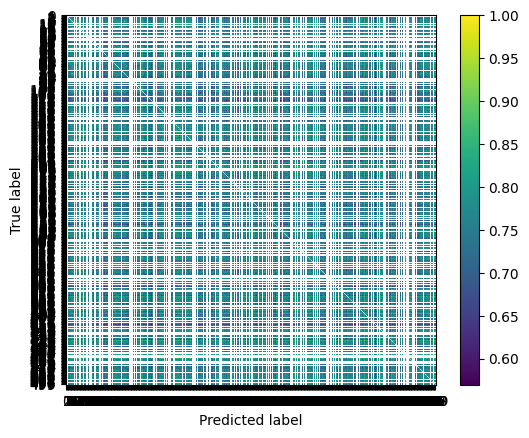

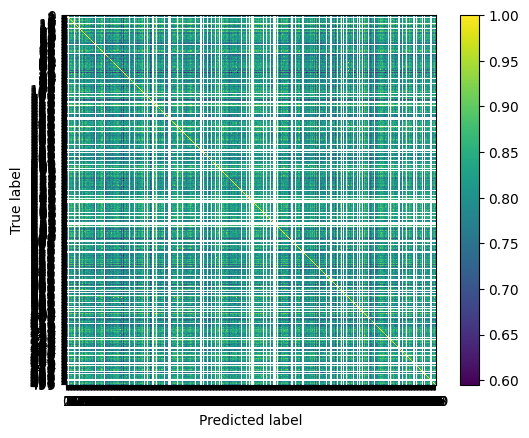

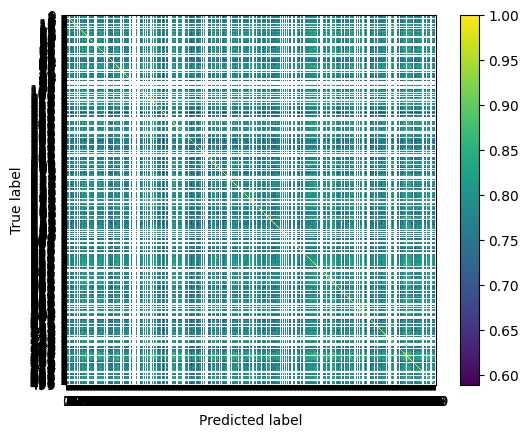

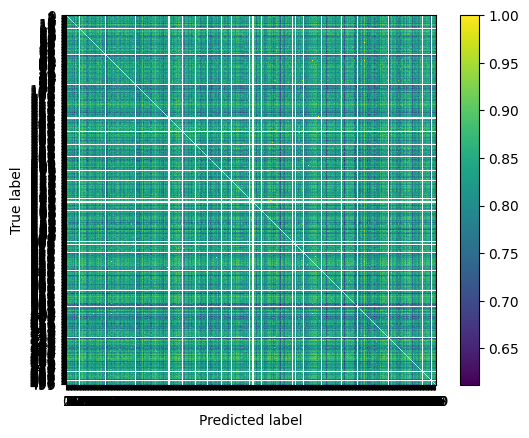

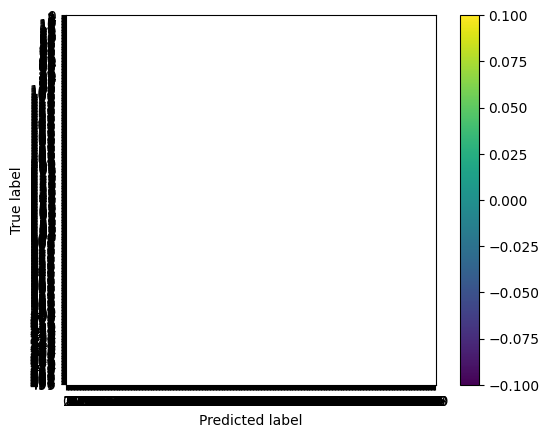

In [42]:
import pylab

disp = ConfusionMatrixDisplay(text_similarities_matrix[:,:,0], display_labels = None)
disp.plot(include_values = False)
pylab.show()
disp = ConfusionMatrixDisplay(text_similarities_matrix[:,:,1], display_labels = None)
disp.plot(include_values = False)
pylab.show()
disp = ConfusionMatrixDisplay(text_similarities_matrix[:,:,2], display_labels = None)
disp.plot(include_values = False)
pylab.show()
disp = ConfusionMatrixDisplay(text_similarities_matrix[:,:,3], display_labels = None)
disp.plot(include_values = False)
pylab.show()
disp = ConfusionMatrixDisplay(text_similarities_matrix[:,:,4], display_labels = None)
disp.plot(include_values = False)
pylab.show()

In [43]:
text_similarities_matrix = np.nan_to_num(text_similarities_matrix, nan = 1e-3)

## Кластеризация (?)

In [44]:
true_clusters = red_udcc

In [45]:
from sklearn.cluster import SpectralClustering
clustering = SpectralClustering(n_clusters=len(np.unique(true_clusters)), affinity='precomputed', random_state = 0).fit(text_similarities_matrix[:,:,0])
print(bcb_clust(clustering.labels_, true_clusters))
from sklearn.cluster import SpectralClustering
clustering = SpectralClustering(n_clusters=len(np.unique(true_clusters)), affinity='precomputed', random_state = 0).fit(text_similarities_matrix[:,:,1])
print(bcb_clust(clustering.labels_, true_clusters))
from sklearn.cluster import SpectralClustering
clustering = SpectralClustering(n_clusters=len(np.unique(true_clusters)), affinity='precomputed', random_state = 0).fit(text_similarities_matrix[:,:,2])
print(bcb_clust(clustering.labels_, true_clusters))
from sklearn.cluster import SpectralClustering
clustering = SpectralClustering(n_clusters=len(np.unique(true_clusters)), affinity='precomputed', random_state = 0).fit(text_similarities_matrix[:,:,3])
print(bcb_clust(clustering.labels_, true_clusters))
from sklearn.cluster import SpectralClustering
clustering = SpectralClustering(n_clusters=len(np.unique(true_clusters)), affinity='precomputed', random_state = 0).fit(text_similarities_matrix[:,:,4])
print(bcb_clust(clustering.labels_, true_clusters))

(0.36042500382721676, 0.35951466085255795, 0.3547722717511244)
(0.36469731981335163, 0.3703898359972436, 0.3644009835652752)
(0.3031019842273715, 0.30297816823508716, 0.29905847692893256)
(0.4078358777649916, 0.4813415286617397, 0.4348687249179755)
(0.25908117401449093, 0.9190982915711454, 0.3864901799488939)


In [46]:
import random
import numpy as np

def random_segmentation(true_seg):
    claster_count = len(np.unique(true_seg))
    random_clasters = []
    for _ in true_seg:
        random_clasters.append(random.choice(range(claster_count)))
    return random_clasters

bcb_clust(random_segmentation(true_clusters), true_clusters)

(0.2562853164462653, 0.2532833341349114, 0.2534198875563746)

## Оценка